# Pain & Opportunity Research Dashboard

Analysis of business pains solvable by AI agents. Data comes from the 3-stage pipeline:
`sources.csv` -> `pains.csv` -> `opportunities.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

data_dir = Path("../data")

sources = pd.read_csv(data_dir / "sources.csv")
pains = pd.read_csv(data_dir / "pains.csv")
opps = pd.read_csv(data_dir / "opportunities.csv")

print(f"Sources explored: {len(sources)}")
print(f"Pains discovered: {len(pains)}")
print(f"Opportunities graduated: {len(opps)}")

Sources explored: 34
Pains discovered: 46
Opportunities graduated: 15


## Research Pipeline Funnel
How many pains at each stage of the pipeline?

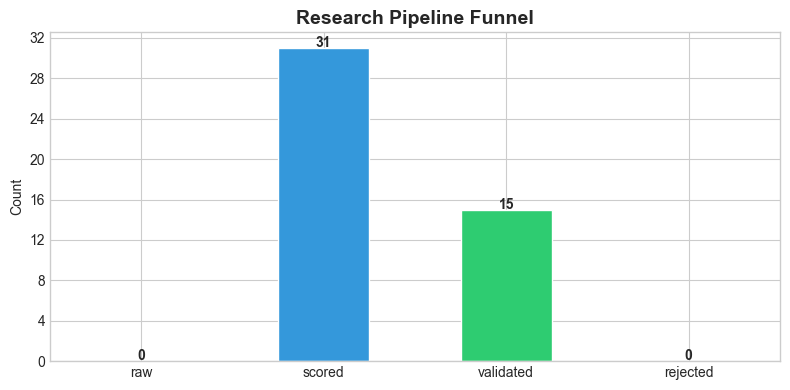

In [2]:
if len(pains) > 0:
    status_order = ["raw", "scored", "validated", "rejected"]
    status_counts = pains["status"].value_counts().reindex(status_order, fill_value=0)

    colors = {"raw": "#95a5a6", "scored": "#3498db", "validated": "#2ecc71", "rejected": "#e74c3c"}
    bar_colors = [colors.get(s, "#95a5a6") for s in status_order]

    fig, ax = plt.subplots(figsize=(8, 4))
    status_counts.plot(kind="bar", color=bar_colors, ax=ax, edgecolor="white")
    ax.set_title("Research Pipeline Funnel", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for i, v in enumerate(status_counts.values):
        ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No pains data yet. Run a research session to populate data/pains.csv.")

## Pain Prioritization Matrix
Scatter plot of **Pain Cost** (y-axis) vs **Solution Ease** (x-axis).
Top-right quadrant = high cost pains that are easy to solve = best opportunities.

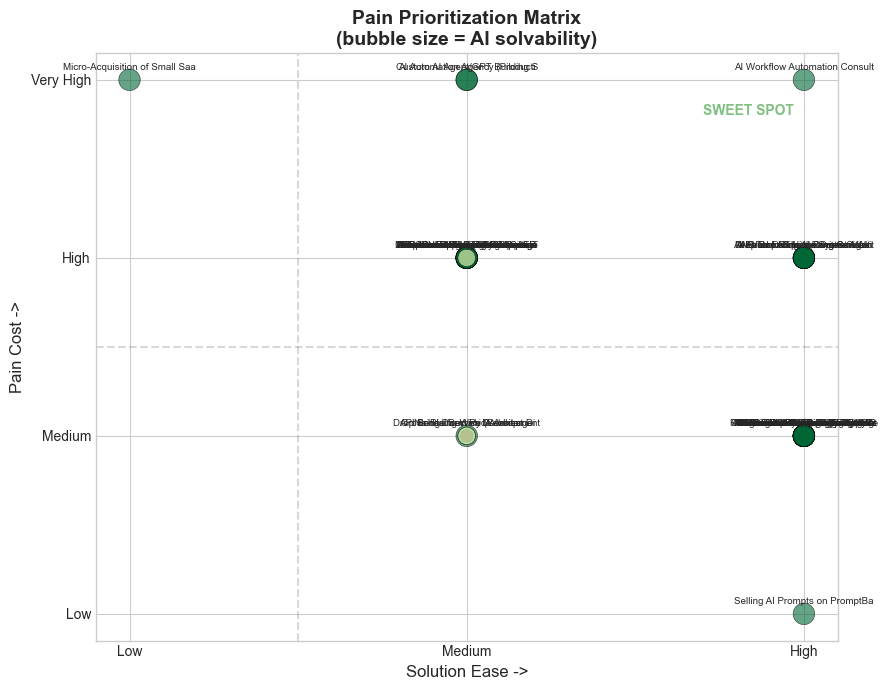

In [3]:
if len(pains) > 0:
    cost_map = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
    ease_map = {"Low": 1, "Medium": 2, "High": 3}
    solv_map = {"Low": 1, "Medium": 2, "High": 3}

    scored = pains[pains["status"].isin(["scored", "validated"])].copy()
    if len(scored) > 0:
        scored["cost_num"] = scored["pain_cost"].map(cost_map)
        scored["ease_num"] = scored["solution_ease"].map(ease_map)
        scored["solv_num"] = scored["ai_solvability"].map(solv_map)

        fig, ax = plt.subplots(figsize=(9, 7))
        scatter = ax.scatter(
            scored["ease_num"],
            scored["cost_num"],
            s=scored["solv_num"] * 80,
            alpha=0.6,
            c=scored["solv_num"],
            cmap="RdYlGn",
            edgecolors="black",
            linewidth=0.5,
        )
        for _, row in scored.iterrows():
            ax.annotate(
                row["pain_name"][:30],
                (row["ease_num"], row["cost_num"]),
                fontsize=7,
                ha="center",
                va="bottom",
                textcoords="offset points",
                xytext=(0, 6),
            )
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(["Low", "Medium", "High"])
        ax.set_yticks([1, 2, 3, 4])
        ax.set_yticklabels(["Low", "Medium", "High", "Very High"])
        ax.set_xlabel("Solution Ease ->", fontsize=12)
        ax.set_ylabel("Pain Cost ->", fontsize=12)
        ax.set_title("Pain Prioritization Matrix\n(bubble size = AI solvability)", fontsize=14, fontweight="bold")

        ax.axhline(y=2.5, color="gray", linestyle="--", alpha=0.3)
        ax.axvline(x=1.5, color="gray", linestyle="--", alpha=0.3)
        ax.text(2.7, 3.8, "SWEET SPOT", fontsize=10, color="green", alpha=0.5, fontweight="bold")

        plt.tight_layout()
        plt.show()
    else:
        print("No scored/validated pains yet. Score some raw pains first.")
else:
    print("No pains data yet.")

## Pains by Industry
Distribution of discovered pains across industries.

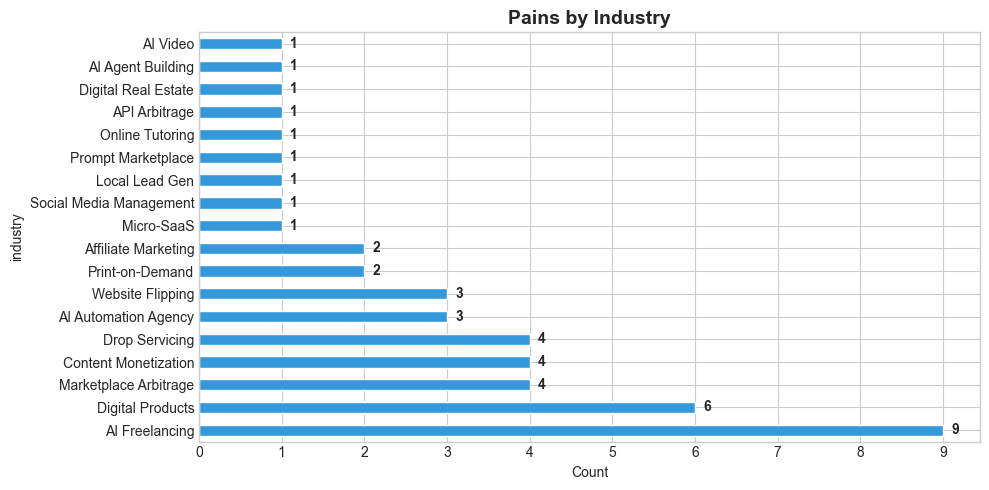

In [4]:
if len(pains) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    industry_counts = pains["industry"].value_counts()
    industry_counts.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
    ax.set_title("Pains by Industry", fontsize=14, fontweight="bold")
    ax.set_xlabel("Count")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for i, v in enumerate(industry_counts.values):
        ax.text(v + 0.1, i, str(v), va="center", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No pains data yet.")

## Best Opportunities
Opportunities sorted by priority score (highest first).

In [6]:
if len(opps) > 0:
    best = opps.sort_values("priority_score", ascending=False).copy()
    if len(pains) > 0:
        best = best.merge(
            pains[["id", "pain_name", "industry", "pain_cost", "ai_solvability"]],
            left_on="pain_id",
            right_on="id",
            suffixes=("", "_pain"),
        )
    display_cols = [
        "priority_score", "pain_name", "industry", "proposed_solution",
        "revenue_model", "target_customer", "estimated_complexity", "competition_notes"
    ]
    available_cols = [c for c in display_cols if c in best.columns]
    display(best[available_cols].style
        .background_gradient(subset=["priority_score"], cmap="RdYlGn")
        .format({"priority_score": "{:.1f}"})
    )
else:
    print("No opportunities graduated yet. Validate pains and graduate the best ones.")

,priority_score,pain_name,industry,proposed_solution,revenue_model,target_customer,estimated_complexity,competition_notes
0,8.3,AI Workflow Automation Consulting,AI Freelancing,"Step 1: Pick a niche vertical (real estate, dental, e-commerce). Step 2: Learn Zapier/Make basics (free tiers, 1-2 days). Step 3: Build 2-3 demo automations for your niche (connect CRM to email to spreadsheet). Step 4: Create Upwork profile as 'AI Automation Specialist for [Niche]'. Step 5: Offer free audit of first client's workflow to land first gig. Step 6: Deliver automation, upsell monthly retainer ($500-2K/mo). Step 7: Document templates, reuse across clients for scalability. Timeline: first client in 1-2 weeks.",$75-200/hr project work + $500-2K/mo retainers per client. Target 3-5 retainer clients = $5K-10K/mo within 3 months.,Small businesses in specific verticals (real estate agencies dental offices e-commerce brands),Medium,Growing but not saturated -- most freelancers are generalists. Niche specialization is the moat. Upwork AI automation category grew 60% YoY. Key edge: pick an underserved vertical and become the go-to expert.
1,7.5,AI Prompt Engineering Consulting,AI Freelancing,"Step 1: Build a portfolio of 5-10 custom GPTs solving specific business problems (e.g. customer email responder, content calendar generator, sales script writer). Step 2: Create a one-page website or Notion page showcasing results. Step 3: List on Upwork as 'AI/Prompt Engineering Consultant'. Step 4: Offer a free 30-min 'AI Readiness Assessment' to attract leads. Step 5: Sell $2K-5K half-day workshops to SMBs. Step 6: Create prompt library templates you can license/sell repeatedly. Timeline: first paid workshop within 2-3 weeks.",$200-500/hr consulting + $2K-5K per workshop. Also sell prompt library subscriptions at $50-200/mo. Target 4-6 workshops/mo = $8K-30K/mo at scale.,Companies and teams adopting AI tools,Low,Market is growing fast as AI adoption increases. Competition exists but most 'prompt engineers' lack business consulting skills. Edge: frame it as business consulting not tech -- focus on ROI and workflow outcomes.
2,7.5,AI Lead Follow-Up Systems for Specific Industries,AI Automation Agency,"Step 1: Pick one industry where lead speed matters (real estate, insurance, home services, auto dealers). Step 2: Build a demo: AI chatbot or email responder that instantly engages new leads using ChatGPT API + Zapier. Step 3: Show the demo to 10 businesses in your niche via cold email/LinkedIn. Pitch: 'You're losing $X per month in leads that go cold.' Step 4: Charge $500-2K setup + $200-500/mo management. Step 5: Use n8n or Make for the backend automation. Step 6: Monitor and optimize response quality. Step 7: Get testimonials and referrals from first clients. Step 8: Scale to 15-20 clients on retainer. Timeline: first client in 1-2 weeks.",$500-2K setup + $200-500/mo per client. Target 15-20 clients = $3-10K/mo in retainers. Setup fees add another $2-5K/mo during growth.,Business owners in lead-dependent industries (real estate agents insurance brokers contractors),Low,Niche but powerful. Most businesses respond to leads in hours -- AI responds in seconds. Harvard Business Review study showed 5-minute response time increases conversion 10x. This is a measurable ROI pitch that sells itself. Competition is low in most local markets.
3,7.5,Drop Servicing AI Content Agency,Drop Servicing,"Step 1: Choose a content niche (SaaS blogs, e-commerce product descriptions, real estate listings, social media for restaurants). Step 2: Build a simple landing page/website showcasing your service and sample work. Step 3: Source 3-5 reliable AI-assisted writers on Fiverr/Upwork who deliver quality work at $20-50/piece. Step 4: Test them with paid trial assignments. Step 5: Price your services at $75-200/piece to clients. Step 6: Acquire first clients via LinkedIn outreach, cold email, or local business networking. Step 7: Manage workflow: receive client brief -> send to writer with

## Research Coverage
How many sources explored and pains found per industry?

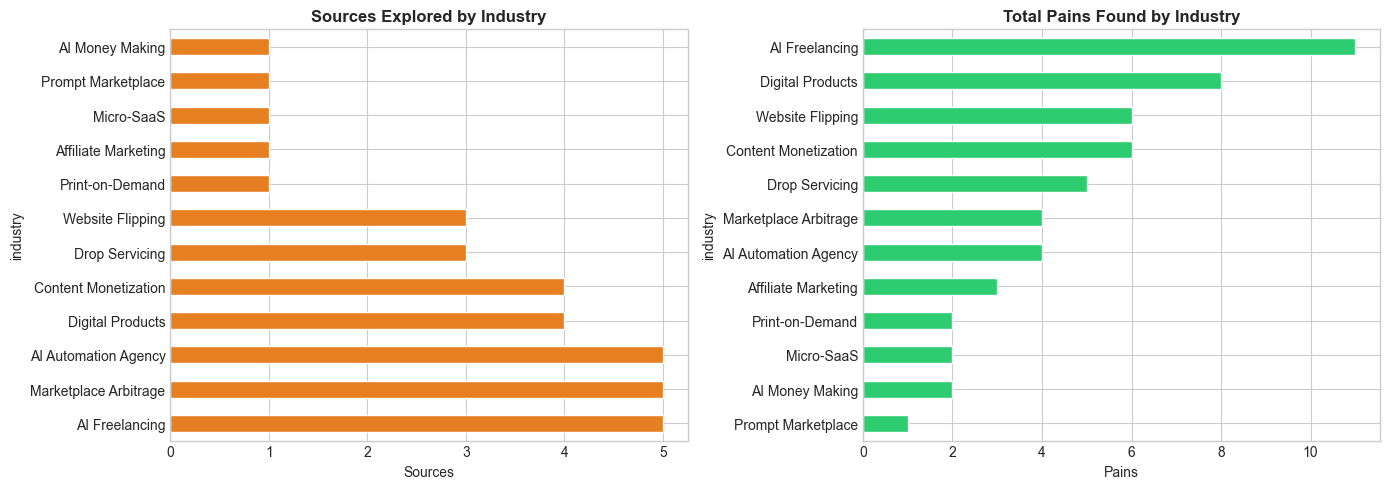

In [7]:
if len(sources) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    src_by_ind = sources["industry"].value_counts()
    src_by_ind.plot(kind="barh", ax=axes[0], color="#e67e22", edgecolor="white")
    axes[0].set_title("Sources Explored by Industry", fontweight="bold")
    axes[0].set_xlabel("Sources")
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    src_yield = sources.groupby("industry")["findings_count"].sum().sort_values(ascending=True)
    src_yield.plot(kind="barh", ax=axes[1], color="#2ecc71", edgecolor="white")
    axes[1].set_title("Total Pains Found by Industry", fontweight="bold")
    axes[1].set_xlabel("Pains")
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()
else:
    print("No sources explored yet. Start a research session!")